In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
import shap
import pickle



In [14]:
# 1. Load data and drop non‑informative columns
df = pd.read_csv('European_Bank (1).csv')
df.drop(['CustomerId', 'Surname', 'Year'], axis=1, inplace=True)

# 2. CREATE DERIVED FEATURES (on the full df)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Active_Products']     = df['IsActiveMember'] * df['NumOfProducts']
df['Age_Tenure']          = df['Age'] * df['Tenure']

# 3. Define X and y AFTER the new columns exist
X = df.drop('Exited', axis=1)
y = df['Exited']

# 4. Define numeric columns (original + derived)
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
                'BalanceSalaryRatio', 'ProductsPerTenure', 'Active_Products', 'Age_Tenure']

categorical_cols = ['Geography', 'Gender']

# 5. Set up the preprocessor with all numeric columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# 6. Stratified train‑test split (using the new X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 7. Now fit the pipeline – no more KeyError
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(max_iter=1000))])
pipe_lr.fit(X_train, y_train)   # works

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [15]:
# Decision Tree
pipe_dt = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', DecisionTreeClassifier(random_state=42))])
model_dt, proba_dt = evaluate_model(pipe_dt, X_train, X_test, y_train, y_test)

# Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
model_rf, proba_rf = evaluate_model(pipe_rf, X_train, X_test, y_train, y_test)

Accuracy: 0.784
Precision: 0.4701670644391408
Recall: 0.48402948402948404
F1-Score: 0.47699757869249393
ROC-AUC: 0.6723348926738758

Confusion Matrix:
 [[1371  222]
 [ 210  197]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      1593
           1       0.47      0.48      0.48       407

    accuracy                           0.78      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.79      0.78      0.79      2000

Accuracy: 0.8655
Precision: 0.7851239669421488
Recall: 0.4668304668304668
F1-Score: 0.5855161787365177
ROC-AUC: 0.8539880404287186

Confusion Matrix:
 [[1541   52]
 [ 217  190]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75     

In [16]:
# Gradient Boosting
pipe_gb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', GradientBoostingClassifier(random_state=42))])
model_gb, proba_gb = evaluate_model(pipe_gb, X_train, X_test, y_train, y_test)

# XGBoost (install: pip install xgboost)
from xgboost import XGBClassifier
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))])
model_xgb, proba_xgb = evaluate_model(pipe_xgb, X_train, X_test, y_train, y_test)

Accuracy: 0.8685
Precision: 0.7857142857142857
Recall: 0.4864864864864865
F1-Score: 0.6009104704097117
ROC-AUC: 0.8687747840290213

Confusion Matrix:
 [[1539   54]
 [ 209  198]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

Accuracy: 0.8505
Precision: 0.6956521739130435
Recall: 0.47174447174447176
F1-Score: 0.5622254758418741
ROC-AUC: 0.8384470757352113

Confusion Matrix:
 [[1509   84]
 [ 215  192]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.70      0.47      0.56       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74     

In [19]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
# Logistic Regression
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
model_lr, proba_lr = evaluate_model(pipe_lr, X_train, X_test, y_train, y_test)

# Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
model_rf, proba_rf = evaluate_model(pipe_rf, X_train, X_test, y_train, y_test)

# Gradient Boosting
pipe_gb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', GradientBoostingClassifier(random_state=42))])
model_gb, proba_gb = evaluate_model(pipe_gb, X_train, X_test, y_train, y_test)

# XGBoost
from xgboost import XGBClassifier
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))])
model_xgb, proba_xgb = evaluate_model(pipe_xgb, X_train, X_test, y_train, y_test)

Accuracy: 0.806
Precision: 0.5703703703703704
Recall: 0.1891891891891892
F1-Score: 0.28413284132841327
ROC-AUC: 0.7734853497565363

Confusion Matrix:
 [[1535   58]
 [ 330   77]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.89      1593
           1       0.57      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.77      0.81      0.76      2000

Accuracy: 0.8655
Precision: 0.7851239669421488
Recall: 0.4668304668304668
F1-Score: 0.5855161787365177
ROC-AUC: 0.8539880404287186

Confusion Matrix:
 [[1541   52]
 [ 217  190]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      

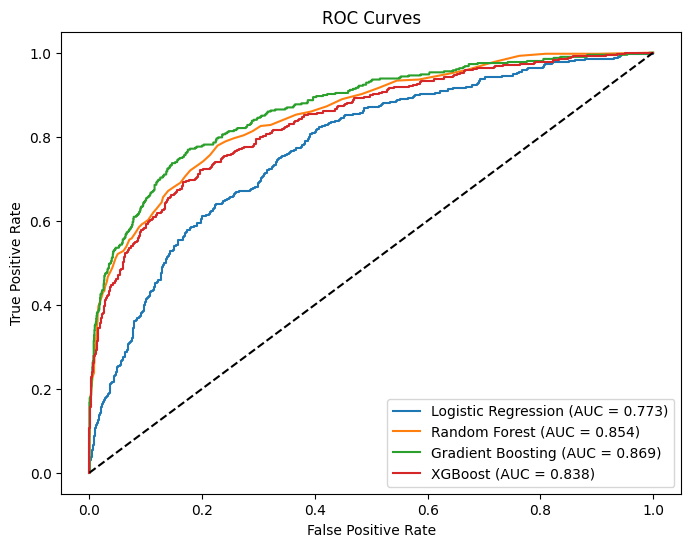

In [22]:
def plot_roc_curves(models, names, X_test, y_test):
    plt.figure(figsize=(8,6))
    for model, name in zip(models, names):
        y_proba = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()

plot_roc_curves([model_lr, model_rf, model_gb, model_xgb],
                ['Logistic Regression','Random Forest','Gradient Boosting','XGBoost'],
                X_test, y_test)

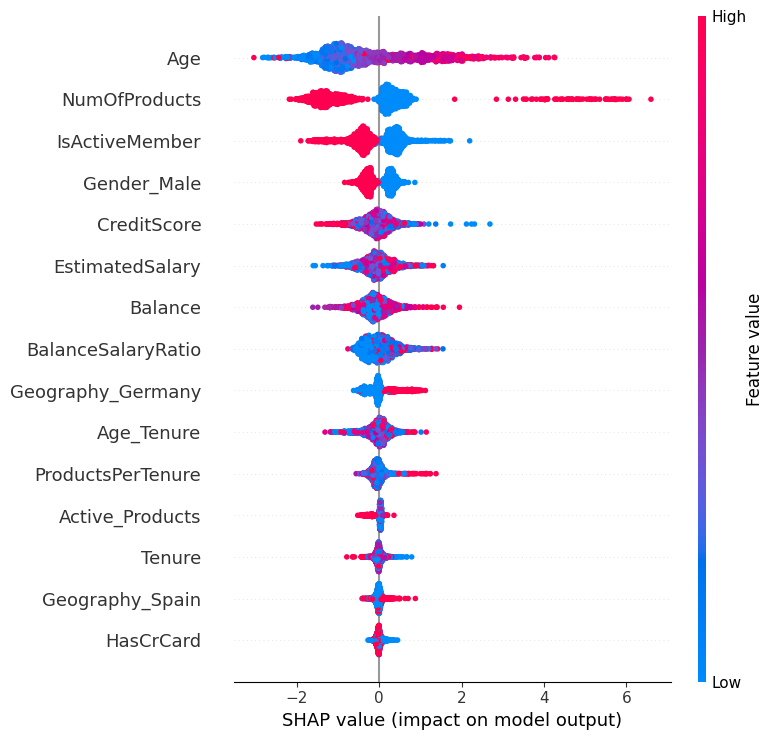

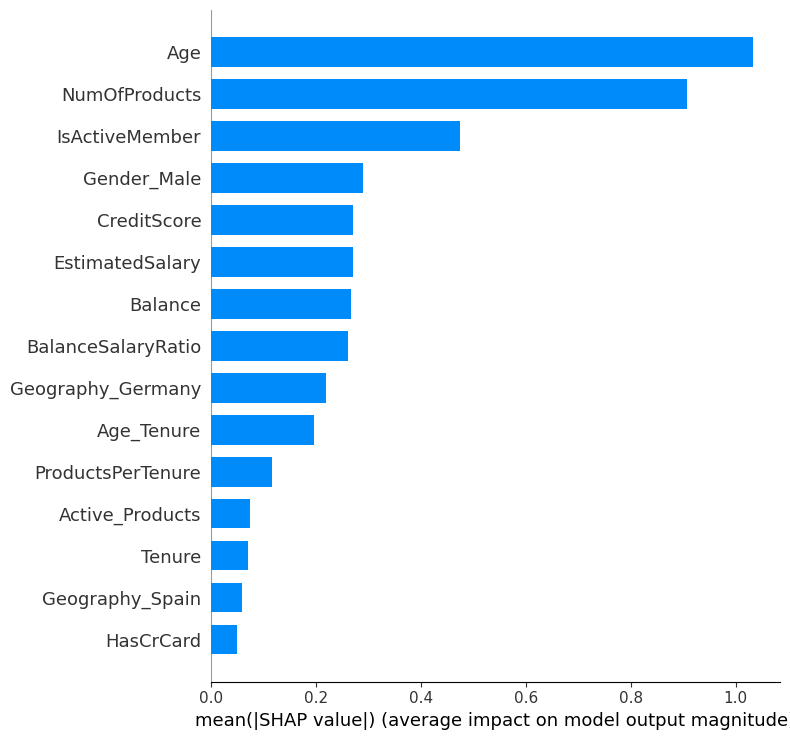

In [23]:
# Transform the test set using the preprocessor
X_test_transformed = preprocessor.transform(X_test)
# Get feature names after one-hot encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = new_numeric + list(cat_features)

# Build SHAP explainer
explainer = shap.TreeExplainer(model_xgb.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# Feature importance bar
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")